# Record repair and openness evidence pool — `eval.py` demo

This notebook is the driver script `eval.py` of **iteration-5, evaluation 4**, split into cells with notes between them.
The evaluation adds no new data and makes no LLM calls. It does three things:

1. **Gates.** G0: all 48 inputs are present. G1 and G2: the published `OPEN_home` partial Spearman (psp) values from Exp10 are reproduced. G3: the copied Eval3 ledger verifier reproduces its own ledger.
2. **Record repair.** Ten MUST-FIX items are fixed through correction blocks applied to a copy of the research report, and the claims ledger (v4, 1,769 rows) is re-checked.
3. **Evidence synthesis.** A descriptive DerSimonian–Laird pool (on Fisher z, with an HKSJ interval) of `OPEN_home` and `NOVCHURN_home` across every body of concepts already scored. It separates **selection** data from **non-selection** data.

**What runs here.** The full `eval.py` first calls six sub-scripts in `src/` (bootstrap estimation, building the corrections, the ledger checks and so on). Those scripts read parquet tables and reports from earlier artifacts in the run, which are not shipped with the demo. This notebook runs the **assembly step** (`eval.py --assemble-only`). That step reads the intermediate results those sub-scripts wrote (`results/*.json|csv`), and they are bundled in `mini_demo_data.json`. From them it computes all gates, the MUST-FIX verdicts, the 124 metrics and the three output datasets.

Two cells go further than the original driver:
* One re-pools the per-body cells with the original `dl_hksj()` function from `src/synthesis.py`, to check the headline pooled numbers.
* One draws the forest plot from `src/figures.py`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports

This is the original import block of `eval.py`, followed by the helpers it imports from `src/paths.py` (`jdump`, `rel`, `sha256` and `_clean`), copied as they are. `RES` (the results folder) points to a local `results/` directory, where the notebook writes `gates.json`. The `sys.path` and `from paths import ...` lines are dropped because `src/` is not shipped. The last lines import `math`, `numpy` and `scipy.stats` for the pooling check, and `matplotlib` for the figure.

In [2]:
from __future__ import annotations

import argparse
import csv
import json
import os
import subprocess
import sys
from pathlib import Path

sys.dont_write_bytecode = True
WS = Path.cwd()   # original: Path(__file__).resolve().parent

from loguru import logger

# ---- from src/paths.py (verbatim helpers; RES points to a local results/ folder)
import hashlib
import math

import numpy as np

RES = WS / "results"
RES.mkdir(parents=True, exist_ok=True)
(WS / "logs").mkdir(parents=True, exist_ok=True)


def rel(p: Path) -> str:
    """WS-relative path string (original: RUN-relative, the ledger's source_file convention)."""
    p = Path(p).resolve()
    return str(p.relative_to(WS))


def _clean(o):
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not math.isfinite(float(o)) else float(o)
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def jdump(p: Path, obj) -> None:
    Path(p).write_text(json.dumps(_clean(obj), indent=1))


def sha256(p: Path) -> str:
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(1 << 20), b""):
            h.update(b)
    return h.hexdigest()

# ---- extra imports for the notebook (pool re-check + visualisation)
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(WS / "logs/eval.log", rotation="30 MB", level="DEBUG")

2

## Load the data

`mini_demo_data.json` holds every file that the assembly step of `eval.py` reads:

| key | original file | what it is |
|---|---|---|
| `evidence_synthesis` | `results/evidence_synthesis.json` | output of `src/synthesis.py`: gates G1/G2, per-body psp cells at R0/R2/R3 with bootstrap CIs and `se_z`, placebo, and pools |
| `ledger_rerun` | `results/ledger_rerun.json` | output of `src/checks.py`: v3 re-verification (G3), v4 ledger, text presence, stale strings, and verbatim checks |
| `corrections_applied` | `results/corrections_applied.csv` | one row per correction block (86 rows), with status APPLIED / ALREADY_PRESENT / … |
| `refs_summary` | `results/refs_summary.json` | counts for the cumulative reference list |
| `per_group_table` | `results/per_group_table.csv` | EXP8 held-out psp per indicator × group (42 rows) |
| `not_found_notes`, `artifact_counts` | `results/*.json` | notes on claims not found in any file, and the artifact counts |
| `inputs_manifest` | `results/inputs_manifest.json` | the G0 manifest of 48 inputs (sha256, bytes), stored as the full run computed it |

The CSV files are stored as lists of row dicts with **string** values, which is exactly what `csv.DictReader` yields. The original code therefore runs unchanged.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if not k.startswith("_")})

{'evidence_synthesis': 6, 'ledger_rerun': 5, 'corrections_applied': 86, 'refs_summary': 9, 'per_group_table': 42, 'not_found_notes': 1, 'artifact_counts': 5, 'inputs_manifest': 3}


## Configuration

These are the command-line arguments of `eval.py` (`--assemble-only`, `--nboot`), and the settings it passes to `src/synthesis.py` (`--nperm 200 --workers 3`).

* `ASSEMBLE_ONLY = True` is required here. The sub-scripts need the upstream parquet files and reports, which are not part of the demo. The per-body bootstrap cells were already computed with `NBOOT = 2000` bootstrap draws and `NPERM = 200` placebo permutations, and are loaded from `data`.
* `MINI_N` is the number of examples per dataset in the `mini_eval_out.json` variant (3 in the original).

The assembly step takes well under a second, so the original values are kept as they are. There is nothing to scale down.

In [5]:
ASSEMBLE_ONLY = True     # original CLI flag --assemble-only; False would re-run src/*.py (needs the full run tree)
NBOOT = "2000"           # original --nboot default: concept-bootstrap draws per psp cell (used by src/synthesis.py)
NPERM = "200"            # outcome permutations for the placebo (passed to src/synthesis.py)
WORKERS = "3"            # process-pool workers for src/synthesis.py
MINI_N = 3               # examples per dataset kept in mini_eval_out.json

## Sub-script runner and helpers

`run()` launches one pipeline sub-script in a subprocess with single-threaded BLAS. It is used only when `ASSEMBLE_ONLY` is False. `inputs_manifest()` builds the G0 manifest by hashing 48 upstream files. Those files are not available here, so the notebook uses the manifest that the full run stored (`data["inputs_manifest"]`), which contains the same fields. `fmt_ci` formats a confidence interval.

In [6]:
def run(script: str, *args: str) -> None:
    env = dict(os.environ, PYTHONDONTWRITEBYTECODE="1", OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
               MKL_NUM_THREADS="1")
    logger.info(f"running {script} {' '.join(args)}")
    r = subprocess.run([sys.executable, str(WS / script), *args], env=env, capture_output=True, text=True)
    (WS / "logs" / f"{Path(script).stem}_stdout.log").write_text(r.stdout + r.stderr)
    if r.returncode:
        raise RuntimeError(f"{script} failed:\n{r.stderr[-1500:]}")


def inputs_manifest() -> dict:
    # original: hashes the 48 upstream files (REPORT5, REPORT4, Eval3 verifier + ledger, Exp8/10/11/12 results and
    # parquets, Research 1-3 outputs). Those paths exist only inside the run tree, so the demo returns the stored copy.
    return data["inputs_manifest"]


def fmt_ci(c):
    return f"[{c[0]:+.3f}, {c[1]:+.3f}]"

## Step 1: G0 input manifest and the (skipped) sub-script pipeline

This is the start of `main()`. The manifest is written to `results/inputs_manifest.json`, and G0 passes if all 48 inputs exist. With `ASSEMBLE_ONLY` set, the six pipeline scripts are skipped. In order, they are:
`synthesis.py` → `build_corrections.py` → `apply_corrections.py` → `refs.py` → `figures.py` → `checks.py`.

In [7]:
class _A:  # stands in for argparse.Namespace (original: ap.parse_args())
    assemble_only = ASSEMBLE_ONLY
    nboot = NBOOT
a = _A()
man = inputs_manifest()
jdump(RES / "inputs_manifest.json", man)
if not man["all_exist"]:
    raise FileNotFoundError([f["path"] for f in man["files"] if not f["exists"]])
if not a.assemble_only:
    run("src/synthesis.py", "--nboot", a.nboot, "--nperm", NPERM, "--workers", WORKERS)
    run("src/build_corrections.py")
    run("src/apply_corrections.py")
    run("src/refs.py")
    run("src/figures.py")
    run("src/checks.py")
print(f"G0: {man['n']} inputs, all_exist={man['all_exist']}")

G0: 48 inputs, all_exist=True


## Step 2: Read the intermediate results and evaluate gates G1–G3

In the original, the four `json.loads(...)` / `csv.DictReader(...)` reads come from `results/`; here they come from `data`.
* **G1**: `OPEN_home` psp on EXP5, recomputed at R0 and R2, must match Exp10's published values to 3 decimals.
* **G2**: the cohort's `OPEN_home` R2 psp and its CI, and the R3 psp, must match Exp10.
* **G3**: re-verifying the v3 ledger must give exactly 1,290 rows, 0 MISMATCH, 0 NOT_FOUND and 9 orphan tokens.

In [8]:
syn = data["evidence_synthesis"]            # json.loads((RES / "evidence_synthesis.json").read_text())
chk = data["ledger_rerun"]                  # json.loads((RES / "ledger_rerun.json").read_text())
app = list(data["corrections_applied"])     # list(csv.DictReader(open(RES / "corrections_applied.csv")))
refs = data["refs_summary"]                 # json.loads((RES / "refs_summary.json").read_text())
g1, g2 = syn["gates"]["G1"], syn["gates"]["G2"]
v3, v4 = chk["a_v3_reverify"], chk["b_v4"]
g3 = (v3["n_rows"] == 1290 and v3["n_mismatch_recomputed"] == 0 and v3["n_not_found_recomputed"] == 0
      and v3["n_orphan_numeric_tokens"] == 9)
gates = {"G0_inputs_exist": man["all_exist"], "G1_R0": g1["pass_R0"], "G1_R2": g1["pass_R2"], "G2": g2["pass"],
         "G3": g3}
jdump(RES / "gates.json", {"gates": gates, "G1": g1, "G2": {k: v for k, v in g2.items()},
                           "G3": {k: v3[k] for k in ("n_rows", "recomputed_status_counts", "n_mismatch_recomputed",
                                                     "n_not_found_recomputed", "n_orphan_numeric_tokens")}})
print(gates)

{'G0_inputs_exist': True, 'G1_R0': True, 'G1_R2': True, 'G2': True, 'G3': True}


## Step 3: The ten MUST-FIX items

Every correction block has a status in `corrections_applied`. A MUST-FIX item counts as **cleared** only when all of these hold:
* each required block (identified by source file and block id) has the status `APPLIED`;
* the item's verbatim checks match byte for byte (where the item has any);
* no stale strings remain, for items 1 and 10;
* no Eval3 block is missing its target section, for item 5.

In [9]:
st = {}
for r in app:
    st[r["status"]] = st.get(r["status"], 0) + 1
by = {(r["source_file"], r["block_id"]): r["status"] for r in app}

def ok(fn, *bids):
    return all(by.get((fn, b)) == "APPLIED" for b in bids)

verb = chk["e_verbatim"]
stale = chk["d_stale"]
eval3_missing = sum(1 for r in app if r["status"] == "NOT_APPLIED_TARGET_MISSING")
mustfix = {
    "1_case_studies_26_4": ok("01_case_studies_26_4.md", "26.4_rebuilt", "26.5_atlas") and stale["n_stale_hits"] == 0,
    "2_exp11_25a": ok("02_exp11_25a.md", "25a_exp11", "29_deadend_exp11", "28.1_c4", "24_counts", "31_counts")
    and verb["Exp11_HM1_HP1_lines_24_32_verbatim"],
    "3_exp10_rewrite": ok("03_exp10_rewrite.md", "25.1", "25.2", "25.4", "25.7", "25.8", "31.1"),
    "4_exp12_rewrite": ok("04_exp12_rewrite.md", "26.1", "26.3", "26.2_pc", "31.3_caveat")
    and all(verb[f"{k}_verbatim"] for k in ("PR1", "PR1b", "PR2", "PR3")),
    "5_eval3_application": eval3_missing == 0 and ok("05_eval3_application.md", "27.6_list"),
    "6_section23_restore": ok("06_section23_restore.md", "23_restore", "16.2_tag") and verb["section23_byte_identical"],
    "7_section28_evidence": ok("07_section28_evidence.md", "28.1_evidence", "28.2_survives", "31.2_retention"),
    "8_secondary": ok("08_exp8_exp10_secondary.md", "25.5_leads", "25.6", "19.5b_tag", "19.7_tag", "19.2_pergroup")
    and verb["Exp10_leads_block_lines_48_53_verbatim"],
    "9_coverage_table_30": ok("09_coverage_table_30.md", "30_table"),
    "10_minor_and_refs": ok("10_minor_and_refs.md", "fcr", "27.3_I2", "27.2_label") and stale["n_stale_hits"] == 0
    and refs["n_master"] > 0}
print("correction status counts:", st)
for k, v in mustfix.items():
    print(f"  {'CLEARED' if v else 'OPEN   '}  {k}")

correction status counts: {'ALREADY_PRESENT': 5, 'APPLIED': 76, 'NOT_APPLIED_SUPERSEDED': 5}
  CLEARED  1_case_studies_26_4
  CLEARED  2_exp11_25a
  CLEARED  3_exp10_rewrite
  CLEARED  4_exp12_rewrite
  CLEARED  5_eval3_application
  CLEARED  6_section23_restore
  CLEARED  7_section28_evidence
  CLEARED  8_secondary
  CLEARED  9_coverage_table_30
  CLEARED  10_minor_and_refs


## Step 4: Flat metrics (`metrics_agg`)

This step collects the ledger counts (v3 and v4), text-presence counts, gate flags and correction counts, together with:
* the per-body R2 psp for each feature;
* for each feature × rung, the **non-selection pool**: its estimate, DL and HKSJ intervals, I², τ², k, the all-bodies pool, the shrinkage ratio (selection estimate divided by non-selection estimate), and sign agreement.

In [10]:
rows = {(r["body"], r["feature"]): r for r in syn["rows"]}
m = {"n_mustfix_cleared": sum(mustfix.values()), "n_mustfix_total": len(mustfix),
     "ledger_v3_rows": v3["n_rows"], "ledger_v3_mismatch": v3["n_mismatch_recomputed"],
     "ledger_v3_not_found": v3["n_not_found_recomputed"], "ledger_v3_orphans": v3["n_orphan_numeric_tokens"],
     "ledger_v4_rows": v4["n_rows"], "ledger_v4_mismatch": v4["n_mismatch_recomputed"],
     "ledger_v4_not_found": v4["n_not_found_recomputed"], "ledger_v4_orphans": v4["n_orphan_numeric_tokens"],
     "ledger_v4_disagreements": v4["n_disagreements"],
     "text_present_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_PRESENT", 0),
     "text_present_elsewhere_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_PRESENT_ELSEWHERE", 0),
     "text_absent_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_ABSENT", 0),
     "text_present_v4": chk["c_text_presence"]["v4"]["counts"].get("TEXT_PRESENT", 0),
     "text_absent_v4": chk["c_text_presence"]["v4"]["counts"].get("TEXT_ABSENT", 0)
     + chk["c_text_presence"]["v4"]["counts"].get("TEXT_PRESENT_ELSEWHERE", 0),
     "stale_hits": stale["n_stale_hits"], "stale_correction_note_mentions": stale["n_correction_note_mentions"],
     "verbatim_checks_passed": sum(verb.values()), "verbatim_checks_total": len(verb),
     "gate_G0_pass": int(gates["G0_inputs_exist"]), "gate_G1_R0_pass": int(gates["G1_R0"]),
     "gate_G1_R2_pass": int(gates["G1_R2"]), "gate_G2_pass": int(gates["G2"]), "gate_G3_pass": int(gates["G3"]),
     "G1_open_home_R0_recomputed": g1["OPEN_home|O2r_m50|R0"]["recomputed"],
     "G1_open_home_R2_recomputed": g1["OPEN_home|O2r_m50|R2"]["recomputed"],
     "G2_cohort_open_home_R2": g2["R2"]["rho"], "G2_cohort_open_home_R3": g2["R3"]["rho"],
     "corrections_applied": st.get("APPLIED", 0), "corrections_already_present": st.get("ALREADY_PRESENT", 0),
     "corrections_not_applied_target_missing": st.get("NOT_APPLIED_TARGET_MISSING", 0),
     "corrections_not_applied_superseded": st.get("NOT_APPLIED_SUPERSEDED", 0),
     "references_master_n": refs["n_master"], "references_cited_n": refs["n_cited"],
     "references_excluded_unverified_n": refs["n_excluded"]}
short = {"B1_DEV": "B1_dev", "B2_HELDOUT_pooled": "B2_heldout_pooled", "B3_EXP5_COHORT_2010_14": "B3_cohort1014",
         "B4_COHORT_2015_17": "B4_cohort1517", "B2_PHYS": "B2_phys", "B2_LIFEENV": "B2_lifeenv", "B2_SOC": "B2_soc",
         "B2_MATHDEC": "B2_mathdec"}
for (b, f), r in rows.items():
    if b in short and r["R2"]["psp"] is not None:
        m[f"psp_R2_{f}_{short[b]}"] = r["R2"]["psp"]
for f in ("OPEN_home", "NOVCHURN_home"):
    for rung in ("R0", "R2", "R3"):
        p = syn["pools"][f"{f}|{rung}"]
        n = p["nonselection"]
        tag = f"{f}_{rung}"
        m[f"pooled_nonselection_{tag}"] = n["est"]
        m[f"pooled_nonselection_{tag}_dl_lo"], m[f"pooled_nonselection_{tag}_dl_hi"] = n["dl_ci"]
        m[f"pooled_nonselection_{tag}_hksj_lo"], m[f"pooled_nonselection_{tag}_hksj_hi"] = n["hksj_ci"]
        m[f"pooled_nonselection_{tag}_I2"] = n["I2"]
        m[f"pooled_nonselection_{tag}_tau2_z"] = n["tau2_z"]
        m[f"pooled_nonselection_{tag}_k"] = n["k"]
        m[f"pooled_all_bodies_{tag}"] = p["all_bodies_includes_selection_data"]["est"]
        m[f"shrinkage_selection_over_nonselection_{tag}"] = p["shrinkage_ratio_selection_over_nonselection"]
        k_pos, k_all = p["sign_agreement_nonselection"].split("/")
        m[f"sign_agreement_nonselection_{tag}_pos"] = int(k_pos)
        m[f"sign_agreement_nonselection_{tag}_k"] = int(k_all)
print(f"{len(m)} metrics")

124 metrics


## Step 5: The three output datasets

Each dataset is a list of examples, and each example has `input`, `output`, `metadata_*` and `eval_*` fields (the `exp_eval_sol_out` schema):
* **`evidence_synthesis`**: one example per body × feature × rung. The empty Frame-N slot shows up as "pending iteration-5 artifact".
* **`per_group_table_exp8_O2r_m50`**: one example per EXP8 held-out indicator × group.
* **`corrections_applied`**: one example per correction block.

In [11]:
ds_syn = []
for r in syn["rows"]:
    for rung in ("R0", "R2", "R3"):
        if rung not in r:
            continue
        c = r[rung]
        ds_syn.append({"input": f"body={r['body']} | feature={r['feature']} | outcome=O2r_m50 | rung={rung} | "
                                f"status={r['status']}",
                       "output": ("pending iteration-5 artifact" if c["psp"] is None else
                                  f"psp {c['psp']:+.3f} {fmt_ci(c['ci'])} n={c['n']}"),
                       "metadata_body": r["body"], "metadata_feature": r["feature"], "metadata_rung": rung,
                       "metadata_status": r["status"], "metadata_n": c.get("n"),
                       **({"eval_psp": c["psp"], "eval_ci_lo": c["ci"][0], "eval_ci_hi": c["ci"][1]}
                          if c["psp"] is not None else {}),
                       **({"eval_placebo_p95_abs_psp": r["placebo"]["p95_abs_psp"]}
                          if "placebo" in r and rung == "R2" else {})})
pg = list(data["per_group_table"])          # list(csv.DictReader(open(RES / "per_group_table.csv")))
ds_pg = [{"input": f"indicator={r['indicator']} | unit={r['unit']} | outcome=O2r_m50 (EXP8 held-out)",
          "output": f"psp {float(r['psp']):+.3f} [{float(r['ci_lo']):+.3f}, {float(r['ci_hi']):+.3f}] "
                    f"n={r['n']}{' (CI includes 0)' if r['ci_includes_0'] == 'True' else ''}",
          "metadata_indicator": r["indicator"], "metadata_unit": r["unit"],
          "eval_psp": float(r["psp"]), "eval_ci_lo": float(r["ci_lo"]), "eval_ci_hi": float(r["ci_hi"]),
          "eval_n": int(r["n"]), "eval_ci_includes_0": int(r["ci_includes_0"] == "True")} for r in pg]
ds_app = [{"input": f"{r['source_file']} :: {r['block_id']} -> {r['target_section']} ({r['action']})",
           "output": f"{r['status']}: {r['reason']}", "metadata_source_file": r["source_file"],
           "metadata_status": r["status"],
           "eval_applied": int(r["status"] == "APPLIED"),
           "eval_line_in_corrected": int(r["line_in_corrected_final"])} for r in app]
print(len(ds_syn), len(ds_pg), len(ds_app))
print(ds_syn[3]["input"], "->", ds_syn[3]["output"])

50 42 86
body=B1_DEV | feature=NOVCHURN_home | outcome=O2r_m50 | rung=R0 | status=selection -> psp +0.125 [+0.088, +0.162] n=2741


## Step 6: Assemble `eval_out.json` and its full, mini and preview variants

The metadata records the plan, the zero-spend and no-new-data flags, the verdict for each MUST-FIX item, the gates, the estimator design, what is **not** claimed, and the deviations from the plan. `mini_eval_out.json` keeps `MINI_N` examples per dataset. `preview_eval_out.json` also cuts every string to 200 characters.

In [12]:
out = {"metadata": {
    "evaluation_name": "Fix the record and pool the openness evidence (iteration 5, evaluation 4)",
    "plan": "3_invention_loop/iter_5/gen_plan/gen_plan_evaluation_1",
    "llm_spend_usd": 0.0, "openalex_credit": 0, "new_data": False, "unseal": False,
    "mustfix": mustfix, "gates": gates,
    "estimator": syn["design"]["estimator"], "synthesis_design": syn["design"],
    "status_labels": {"selection": "data on which the index / constants were chosen",
                      "already-unsealed": "held-out data whose outcomes earlier artifacts had read",
                      "confirmatory": "never used before the test",
                      "pending iteration-5 artifact": "Frame N slot, empty"},
    "not_claimed": ["no new confirmation: the pooled estimate is descriptive and uses already-unsealed bodies",
                    "NOVCHURN_home on the 2015-17 cohort is a selection estimate",
                    "the ledger checks numbers against files, not the reasoning around them"],
    "not_found_notes": data["not_found_notes"],        # json.loads((RES / "not_found_notes.json").read_text())
    "deviations": [
        "bootstrap seed = Exp10's frozen 20260929 (plan said 0) so every CI is comparable with the record; G2 was "
        "also run with seed 0 (CI within +-0.005, reported in results/gates_g1_g2.json)",
        "DL pooling on Fisher z (plan) whereas Exp10 pooled raw psp; reported values are back-transformed",
        "the 37-concept AI atlas is atlas.json -> concepts (ai_atlas/table.csv is the per-measure median table)",
        "the OPEN~PC1/PC2 table is read from trajectories_dev/heldout.json (open_diagnostics.json has no PC table)",
        "reference de-duplication uses first-author surname + year + first 5 words of the title head (before "
        "':' or '?') and a prefix pass, because the end-of-report list abbreviates titles",
        "Eval3 blocks already present with >= 90% of their numbers are marked ALREADY_PRESENT; partial ones are "
        "appended in full with a note",
        "the review's 'Exp8 raw sign flip +0.143 / -0.126' is not in any file (NOT_FOUND) and is not used"],
    "artifact_counts": data["artifact_counts"],        # json.loads((RES / "artifact_counts.json").read_text())
    "references": refs},
    "metrics_agg": {k: float(v) for k, v in m.items() if v is not None},
    "datasets": [{"dataset": "evidence_synthesis", "examples": ds_syn},
                 {"dataset": "per_group_table_exp8_O2r_m50", "examples": ds_pg},
                 {"dataset": "corrections_applied", "examples": ds_app}]}
jdump(WS / "eval_out.json", out)
jdump(WS / "full_eval_out.json", out)
mini = dict(out, datasets=[dict(d, examples=d["examples"][:MINI_N]) for d in out["datasets"]])
jdump(WS / "mini_eval_out.json", mini)

def trunc(o):
    if isinstance(o, str):
        return o[:200]
    if isinstance(o, list):
        return [trunc(x) for x in o]
    if isinstance(o, dict):
        return {k: trunc(v) for k, v in o.items()}
    return o
jdump(WS / "preview_eval_out.json", trunc(mini))
logger.info(f"must-fix cleared {m['n_mustfix_cleared']}/10: {mustfix}")
logger.info(f"gates {gates}; metrics {len(m)}")

21:34:27|INFO   |must-fix cleared 10/10: {'1_case_studies_26_4': True, '2_exp11_25a': True, '3_exp10_rewrite': True, '4_exp12_rewrite': True, '5_eval3_application': True, '6_section23_restore': True, '7_section28_evidence': True, '8_secondary': True, '9_coverage_table_30': True, '10_minor_and_refs': True}


21:34:27|INFO   |gates {'G0_inputs_exist': True, 'G1_R0': True, 'G1_R2': True, 'G2': True, 'G3': True}; metrics 124


## Check: re-pool the per-body cells with the original `dl_hksj()`

`dl_hksj` is copied unchanged from `src/synthesis.py`. It runs a DerSimonian–Laird random-effects pool on Fisher-z-transformed psp, with each body's bootstrap `se_z`, plus a Hartung–Knapp–Sidik–Jonkman interval with a *t*(k−1) critical value, and back-transforms the result to *r*.

The **non-selection** pool uses the four held-out groups plus the 2010–14 EXP5 cohort, and adds the 2015–17 cohort for `OPEN_home` only (for `NOVCHURN_home` that cohort is where the index was chosen). The recomputed values should equal the stored `pools` exactly.

In [13]:
def dl_hksj(rows: list[dict]) -> dict:
    """DL random effects on Fisher z (se_z from the bootstrap) + HKSJ interval; back-transformed to r."""
    z = np.array([math.atanh(r["rho"]) for r in rows])
    se = np.array([r["se_z"] for r in rows])
    k = len(z)
    w = 1 / se**2
    zf = (w * z).sum() / w.sum()
    Q = float((w * (z - zf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 else 0.0
    ws = 1 / (se**2 + tau2)
    mu = float((ws * z).sum() / ws.sum())
    se_dl = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    q = float((ws * (z - mu) ** 2).sum() / (k - 1)) if k > 1 else math.nan
    se_hk = math.sqrt(q / ws.sum()) if k > 1 else math.nan
    t = stats.t.ppf(0.975, k - 1) if k > 1 else math.nan
    th = math.tanh
    return {"k": k, "est": th(mu), "dl_ci": [th(mu - 1.96 * se_dl), th(mu + 1.96 * se_dl)],
            "hksj_ci": [th(mu - t * se_hk), th(mu + t * se_hk)] if k > 1 else [math.nan, math.nan],
            "Q": Q, "I2": float(I2), "tau2_z": float(tau2), "z": mu, "se_z_dl": se_dl, "se_z_hksj": se_hk,
            "I2_note": "imprecise at small k (k <= 6)"}

HELD = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
heldg = [f"B2_{g}" for g in HELD]
print(f"{'feature|rung':<18}{'stored':>9}{'recomputed':>12}{'DL CI':>20}{'HKSJ CI':>20}{'I2':>6}{'k':>3}")
for f in ("OPEN_home", "NOVCHURN_home"):
    for rung in ("R0", "R2", "R3"):
        nonsel = heldg + ["B3_EXP5_COHORT_2010_14"] + (["B4_COHORT_2015_17"] if f == "OPEN_home" else [])
        cs = [{"rho": rows[(b, f)][rung]["psp"], "se_z": rows[(b, f)][rung]["se_z"], "body": b} for b in nonsel]
        cs = [c for c in cs if np.isfinite(c["rho"]) and np.isfinite(c["se_z"])]
        p = dl_hksj(cs)
        stored = syn["pools"][f"{f}|{rung}"]["nonselection"]["est"]
        assert abs(p["est"] - stored) < 1e-12, (f, rung, p["est"], stored)
        print(f"{f + '|' + rung:<18}{stored:>+9.3f}{p['est']:>+12.3f}{fmt_ci(p['dl_ci']):>20}{fmt_ci(p['hksj_ci']):>20}"
              f"{p['I2']:>6.2f}{p['k']:>3}")

feature|rung         stored  recomputed               DL CI             HKSJ CI    I2  k
OPEN_home|R0         +0.086      +0.086    [+0.055, +0.116]    [+0.047, +0.124]  0.00  6
OPEN_home|R2         +0.069      +0.069    [+0.038, +0.100]    [+0.042, +0.096]  0.00  6
OPEN_home|R3         +0.057      +0.057    [+0.026, +0.088]    [+0.036, +0.078]  0.00  6
NOVCHURN_home|R0     +0.110      +0.110    [+0.075, +0.146]    [+0.084, +0.137]  0.00  5
NOVCHURN_home|R2     +0.105      +0.105    [+0.069, +0.140]    [+0.078, +0.131]  0.00  5
NOVCHURN_home|R3     +0.095      +0.095    [+0.058, +0.131]    [+0.079, +0.111]  0.00  5


## Results

The first block below summarises the gates, the MUST-FIX items and the ledger. The table after it lists each body's R2 psp next to its placebo 95th percentile. The figure is the forest plot from `src/figures.py`, using its fallback palette because the house-style module is not available in this environment.

How to read the plot:
* **Grey** markers are **selection** data.
* **Hollow** markers are **already-unsealed** held-out data.
* **Filled blue** markers are **confirmatory** data.
* The orange diamond is the non-selection DL pool, and the thin line beneath it is its HKSJ interval.
* The dashed row is the empty Frame-N slot.

In [14]:
print("=" * 78)
print(f"MUST-FIX cleared : {m['n_mustfix_cleared']}/{m['n_mustfix_total']}")
print(f"Gates            : {gates}")
print(f"Ledger v3        : {m['ledger_v3_rows']:.0f} rows, {m['ledger_v3_mismatch']:.0f} MISMATCH, "
      f"{m['ledger_v3_not_found']:.0f} NOT_FOUND, {m['ledger_v3_orphans']:.0f} orphans")
print(f"Ledger v4        : {m['ledger_v4_rows']:.0f} rows, {m['ledger_v4_mismatch']:.0f} MISMATCH, "
      f"{m['ledger_v4_not_found']:.0f} NOT_FOUND, {m['ledger_v4_orphans']:.0f} orphans")
print(f"Corrections      : {st}")
print(f"Verbatim checks  : {m['verbatim_checks_passed']}/{m['verbatim_checks_total']}; stale hits {m['stale_hits']}")
print(f"References       : {refs['n_master']} master, {refs['n_excluded']} unverified excluded")
print("=" * 78)
print(f"{'body':<26}{'feature':<15}{'status':<30}{'psp R2':>8}{'95% CI':>20}{'n':>6}{'plc p95':>9}")
for r in syn["rows"]:
    c = r["R2"]
    if c["psp"] is None:
        print(f"{r['body']:<26}{r['feature']:<15}{r['status']:<30}{'—':>8}")
        continue
    print(f"{r['body']:<26}{r['feature']:<15}{r['status']:<30}{c['psp']:>+8.3f}{fmt_ci(c['ci']):>20}{c['n']:>6}"
          f"{r['placebo']['p95_abs_psp']:>9.3f}")
for f in ("OPEN_home", "NOVCHURN_home"):
    n = syn["pools"][f"{f}|R2"]["nonselection"]
    print(f"POOL non-selection {f:<14} R2: {n['est']:+.3f} DL {fmt_ci(n['dl_ci'])} HKSJ {fmt_ci(n['hksj_ci'])} "
          f"I2 {n['I2']:.2f} k={n['k']}; shrinkage {syn['pools'][f + '|R2']['shrinkage_ratio_selection_over_nonselection']:.2f}")

MUST-FIX cleared : 10/10
Gates            : {'G0_inputs_exist': True, 'G1_R0': True, 'G1_R2': True, 'G2': True, 'G3': True}
Ledger v3        : 1290 rows, 0 MISMATCH, 0 NOT_FOUND, 9 orphans
Ledger v4        : 1769 rows, 0 MISMATCH, 0 NOT_FOUND, 0 orphans
Corrections      : {'ALREADY_PRESENT': 5, 'APPLIED': 76, 'NOT_APPLIED_SUPERSEDED': 5}
Verbatim checks  : 7/7; stale hits 0
References       : 120 master, 10 unverified excluded
body                      feature        status                          psp R2              95% CI     n  plc p95
B1_DEV                    OPEN_home      selection                       +0.109    [+0.073, +0.144]  3003    0.035
B1_DEV                    NOVCHURN_home  selection                       +0.116    [+0.079, +0.153]  2741    0.035
B2_HELDOUT_pooled         OPEN_home      already-unsealed                +0.070    [+0.021, +0.120]  1569    0.056
B2_HELDOUT_pooled         NOVCHURN_home  already-unsealed                +0.113    [+0.061, +0.163]  1404    

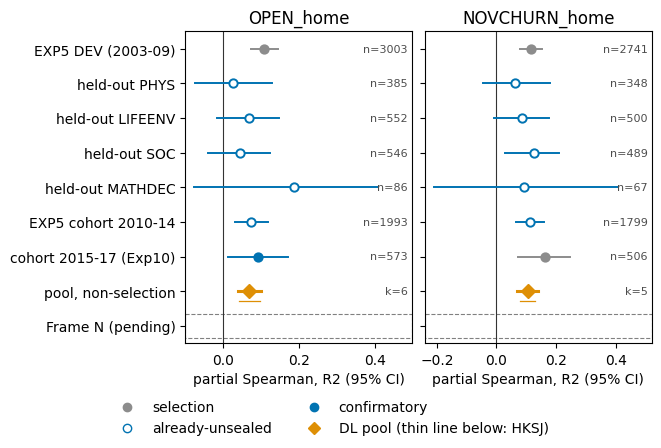

In [15]:
# ---- forest plot: body of src/figures.py main() (HOUSE style off -> fallback PALETTE; figure shown inline)
PALETTE = ["#0173B2", "#DE8F05", "#029E73"]
ORDER = [("B1_DEV", "EXP5 DEV (2003-09)"), ("B2_PHYS", "held-out PHYS"), ("B2_LIFEENV", "held-out LIFEENV"),
         ("B2_SOC", "held-out SOC"), ("B2_MATHDEC", "held-out MATHDEC"),
         ("B3_EXP5_COHORT_2010_14", "EXP5 cohort 2010-14"), ("B4_COHORT_2015_17", "cohort 2015-17 (Exp10)")]
s = syn
rows = {(r["body"], r["feature"]): r for r in s["rows"]}
fig, axes = plt.subplots(1, 2, figsize=(6.5, 4.4), sharey=False, layout="constrained")
for ax, f in zip(axes, ("OPEN_home", "NOVCHURN_home")):
    labels = []
    y = 0
    for b, lab in ORDER:
        r = rows[(b, f)]
        p = r["R2"]
        st_ = r["status"]
        col = "0.55" if st_.startswith("selection") else PALETTE[0]
        face = col if st_ in ("confirmatory",) or st_.startswith("selection") else "white"
        ax.plot(p["ci"], [y, y], color=col, lw=1.4, zorder=2)
        ax.plot([p["psp"]], [y], marker="o", ms=6, mec=col, mfc=face, mew=1.4, ls="none", zorder=3)
        labels.append(lab)
        ax.annotate(f"n={p['n']}", (1.0, y), xycoords=("axes fraction", "data"), xytext=(-3, 0),
                    textcoords="offset points", ha="right", va="center", fontsize=8, color="0.3")
        y += 1
    pool = s["pools"][f"{f}|R2"]["nonselection"]
    ax.plot(pool["hksj_ci"], [y + 0.28, y + 0.28], color=PALETTE[1], lw=0.9, zorder=2)
    ax.plot(pool["dl_ci"], [y, y], color=PALETTE[1], lw=2.2, zorder=2)
    ax.plot([pool["est"]], [y], marker="D", ms=7, color=PALETTE[1], ls="none", zorder=3)
    labels.append("pool, non-selection")
    ax.annotate(f"k={pool['k']}", (1.0, y), xycoords=("axes fraction", "data"), xytext=(-3, 0),
                textcoords="offset points", ha="right", va="center", fontsize=8, color="0.3")
    y += 1
    ax.axhspan(y - 0.35, y + 0.35, fill=False, ls="--", lw=0.8, ec="0.5")
    labels.append("Frame N (pending)")
    ax.axvline(0, color="0.2", lw=0.8, zorder=1)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels if f == "OPEN_home" else [])
    lo, hi = ax.get_xlim()
    ax.set_xlim(lo, hi + 0.12 * (hi - lo))
    ax.set_ylim(len(labels) - 0.5, -0.5)
    ax.set_xlabel("partial Spearman, R2 (95% CI)")
    ax.set_title(f)
handles = [Line2D([], [], marker="o", color="0.55", mfc="0.55", ls="none", label="selection"),
           Line2D([], [], marker="o", color=PALETTE[0], mfc="white", ls="none", label="already-unsealed"),
           Line2D([], [], marker="o", color=PALETTE[0], mfc=PALETTE[0], ls="none", label="confirmatory"),
           Line2D([], [], marker="D", color=PALETTE[1], ls="none", label="DL pool (thin line below: HKSJ)")]
fig.legend(handles=handles, loc="outside lower center", ncol=2, frameon=False)
plt.show()